# Import libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from typing import Tuple, Dict, Any
from sklearn.metrics import f1_score, confusion_matrix, roc_curve, auc
from xgboost import XGBClassifier
import xgboost as xgb
import lightgbm as lgb
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials

# Functions for automation

In [2]:
def split_train_val(df: pd.DataFrame, target_col: str, test_size: float = 0.2, random_state: int = 42) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Split the dataframe into training and validation sets.

    Args:
        df (pd.DataFrame): The raw dataframe.
        target_col (str): The target column for stratification.
        test_size (float): The proportion of the dataset to include in the validation split.
        random_state (int): Random state for reproducibility.

    Returns:
        Tuple[pd.DataFrame, pd.DataFrame]: Training and validation dataframes.
    """
    train_df, val_df = train_test_split(df, test_size=test_size, random_state=random_state, stratify=df[target_col])
    return train_df, val_df


def separate_inputs_targets(df: pd.DataFrame, input_cols: list, target_col: str) -> Tuple[pd.DataFrame, pd.Series]:
    """
    Separate inputs and targets from the dataframe.

    Args:
        df (pd.DataFrame): The dataframe.
        input_cols (list): List of input columns.
        target_col (str): Target column.

    Returns:
        Tuple[pd.DataFrame, pd.Series]: DataFrame of inputs and Series of targets.
    """
    inputs = df[input_cols].copy()
    targets = df[target_col].copy()
    return inputs, targets

In [3]:
def classify_analysis(targets, inputs, model, name = ''):

    pred = model.predict(inputs)
    pred_proba = model.predict_proba(inputs)[:,1]
    pred_class = (pred_proba >= 0.5).astype(int)


    f1_score_value = f1_score(targets, pred_class, pos_label = True)
    print(f'F1 score on {name}: {round(f1_score_value, 4)}')


    cf = confusion_matrix(targets, pred_class, normalize = 'true')
    plt.figure()
    sns.heatmap(cf, annot = True)
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))


    fpr, tpr, thresholds = roc_curve(targets, pred_proba, pos_label = True)

    roc_auc = auc(fpr, tpr)
    print(f'AUROC for {name}: {round(roc_auc, 4)}')


    plt.figure()
    plt.plot(fpr, tpr, color = 'darkorange', lw =2, label = f'ROC curve (area = {round(roc_auc, 2)})')
    plt.plot([0, 1], [0, 1], color = 'navy', lw = 2, linestyle = '--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC for {name}')
    plt.legend(loc = "lower right")
    plt.show()

def importance_features(X_train, model, n=10):
    importance_df = pd.DataFrame({
        "feature": X_train.columns,
        "importance": model.feature_importances_
    }).sort_values('importance', ascending = False).round(4)

    print(f"TOP-{n} найважливіших ознак")
    display(importance_df.head(n))

    plt.title('Feature Importance')
    sns.barplot(data = importance_df.head(10), x = 'importance', y = 'feature');

# Data loading

In [4]:
raw_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

In [5]:
raw_df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15779985.0,Nwankwo,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,1,15650086.0,Ch'in,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,2,15733602.0,Thompson,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,3,15645794.0,Macleod,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,4,15633840.0,Hsia,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0


In [6]:
target_col = 'Exited'
inputs_cols = ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']

In [7]:
train_df, val_df = split_train_val(raw_df, target_col)

In [8]:
train_df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
7180,7180,15652218.0,Mays,682.0,France,Male,30.0,1.0,131394.56,1.0,1.0,1.0,143952.24,0.0
10393,10393,15592937.0,Ch'eng,684.0,France,Female,39.0,2.0,178058.06,1.0,1.0,0.0,145518.31,0.0
80,80,15774586.0,Ch'in,705.0,Germany,Male,35.0,6.0,116320.68,2.0,1.0,0.0,174431.01,0.0
3365,3365,15780572.0,K?,669.0,Spain,Male,58.0,0.0,0.00,2.0,0.0,1.0,51565.98,0.0
12236,12236,15642099.0,Trevisani,707.0,France,Male,21.0,3.0,0.00,2.0,1.0,1.0,148564.76,0.0


In [9]:
train_inputs, train_targets = separate_inputs_targets(train_df, inputs_cols, target_col)
val_inputs, val_targets = separate_inputs_targets(val_df, inputs_cols, target_col)

In [10]:
test_inputs = test_df[inputs_cols].copy()
test_inputs.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86
1,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28
2,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45
3,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87
4,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97


In [11]:
categorical_col = train_inputs.select_dtypes(include = 'object').columns
train_inputs[categorical_col] = train_inputs[categorical_col].astype('category')
val_inputs[categorical_col] = val_inputs[categorical_col].astype('category')
test_inputs[categorical_col] = test_inputs[categorical_col].astype('category')

In [12]:
train_inputs.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12000 entries, 7180 to 9360
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   CreditScore      12000 non-null  float64 
 1   Geography        12000 non-null  category
 2   Gender           12000 non-null  category
 3   Age              12000 non-null  float64 
 4   Tenure           12000 non-null  float64 
 5   Balance          12000 non-null  float64 
 6   NumOfProducts    12000 non-null  float64 
 7   HasCrCard        12000 non-null  float64 
 8   IsActiveMember   12000 non-null  float64 
 9   EstimatedSalary  12000 non-null  float64 
dtypes: category(2), float64(8)
memory usage: 867.4 KB


In [13]:
test_inputs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   CreditScore      10000 non-null  float64 
 1   Geography        10000 non-null  category
 2   Gender           10000 non-null  category
 3   Age              10000 non-null  float64 
 4   Tenure           10000 non-null  float64 
 5   Balance          10000 non-null  float64 
 6   NumOfProducts    10000 non-null  float64 
 7   HasCrCard        10000 non-null  float64 
 8   IsActiveMember   10000 non-null  float64 
 9   EstimatedSalary  10000 non-null  float64 
dtypes: category(2), float64(8)
memory usage: 644.9 KB


# XGBoostClassifier

In [14]:
negative = (train_targets == 0).sum()
positive = (train_targets == 1).sum()
scale_pos_weight = negative / positive

xgb_clf = XGBClassifier(
    max_depth = 5,
    n_estimators = 80,
    enable_categorical = True,
    missing = np.nan,
    device = 'cuda',
    scale_pos_weight = scale_pos_weight,
    random_state = 42
)

xgb_clf.fit(train_inputs, train_targets)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda', early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=80,
              n_jobs=None, num_parallel_tree=None, ...)

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [17:43:35] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


F1 score on Training: 0.831
AUROC for Training: 0.9797


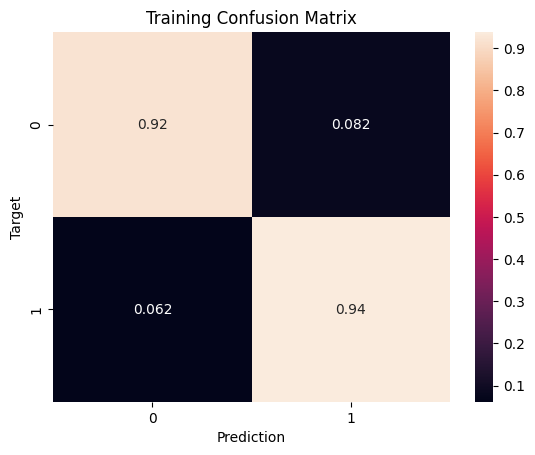

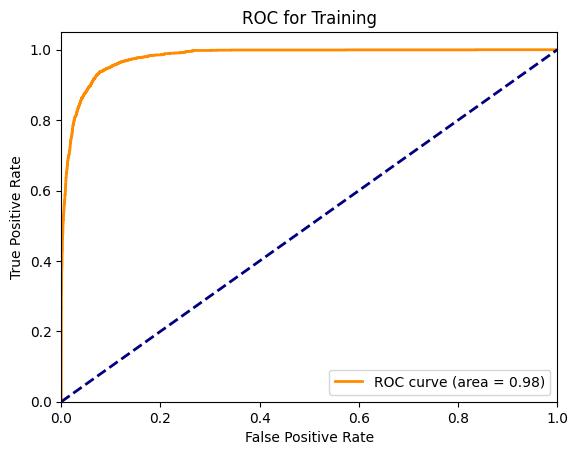

In [15]:
classify_analysis(train_targets, train_inputs, xgb_clf, 'Training')

F1 score on Validation: 0.7221
AUROC for Validation: 0.9285


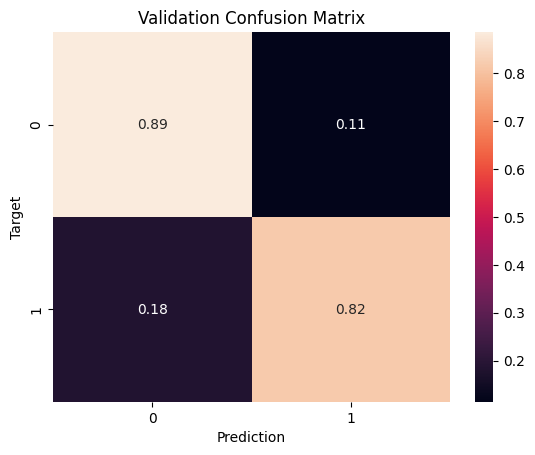

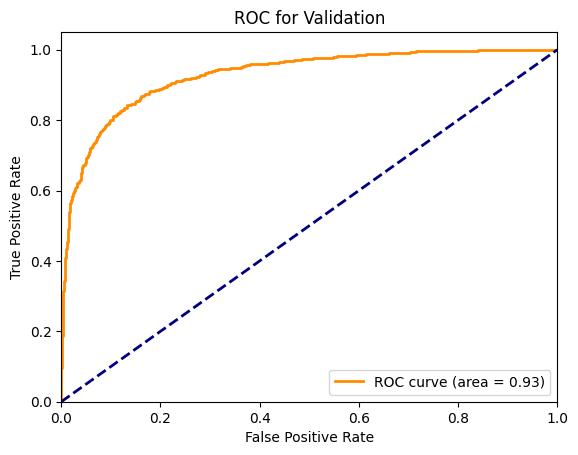

In [16]:
classify_analysis(val_targets, val_inputs, xgb_clf, 'Validation')

The constructed model reflects a fairly high quality on the training data (0.9797), however, on validation we have a lower result (0.9285), which indicates overfitting (respectively, high variance is observed).

At the same time, comparing with the models of previous works, the obtained quality metric is currently lower.

# XGBoostClassifier and Hyperopt

In [17]:
def objective(params):
  clf = xgb.XGBClassifier(
      n_estimators = int(params['n_estimators']),
      learning_rate = params['learning_rate'],
      max_depth = int(params['max_depth']),
      min_child_weight = params['min_child_weight'],
      subsample = params['subsample'],
      colsample_bytree = params['colsample_bytree'],
      gamma = params['gamma'],
      reg_alpha = params['reg_alpha'],
      reg_lambda = params['reg_lambda'],
      enable_categorical = True,
      missing = np.nan,
      device = 'cuda',
      early_stopping_rounds = 10,
      random_state = 42
    )

  clf.fit(
      train_inputs,
      train_targets,
      eval_set = [(val_inputs, val_targets)],
      verbose =2
  )
  pred = clf.predict(val_inputs)
  pred_proba = clf.predict_proba(val_inputs)[:,1]
  fpr, tpr, thresholds = roc_curve(val_targets, pred_proba, pos_label = True)
  roc_auc = auc(fpr, tpr)

  return {'loss': -roc_auc, 'status': STATUS_OK}

# простір гіперпараметрів
space = {
    'n_estimators': hp.quniform('n_estimators', 50, 500, 5),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),
    'max_depth': hp.quniform('max_depth', 3, 25, 1),
    'min_child_weight': hp.quniform('min_child_weight', 1, 10, 1),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0),
    'gamma': hp.uniform('gamma', 0, 0.5),
    'reg_alpha': hp.uniform('reg_alpha', 0, 1),
    'reg_lambda': hp.uniform('reg_lambda', 0, 1)
}

In [18]:
# оптимізація
trials = Trials()
best = fmin(fn = objective, space = space, algo = tpe.suggest, max_evals = 20, trials = trials)

# перетворення значень гіперпараметрів у кінцеві типи
best['n_estimators'] = int(best['n_estimators'])
best['max_depth'] = int(best['max_depth'])
best['min_child_weight'] = int(best['min_child_weight'])

print("Найкращі гіперпараметри: ", best)

[0]	validation_0-logloss:0.48009
[2]	validation_0-logloss:0.44023
[4]	validation_0-logloss:0.40865
[6]	validation_0-logloss:0.38571
[8]	validation_0-logloss:0.37411
[10]	validation_0-logloss:0.35606
[12]	validation_0-logloss:0.34775
[14]	validation_0-logloss:0.33306
[16]	validation_0-logloss:0.32243
[18]	validation_0-logloss:0.31350
[20]	validation_0-logloss:0.30502
[22]	validation_0-logloss:0.29730
[24]	validation_0-logloss:0.29077
[26]	validation_0-logloss:0.28522
[28]	validation_0-logloss:0.28052
[30]	validation_0-logloss:0.27630
[32]	validation_0-logloss:0.27251
[34]	validation_0-logloss:0.26931
[36]	validation_0-logloss:0.26624
[38]	validation_0-logloss:0.26436
[40]	validation_0-logloss:0.26159
[42]	validation_0-logloss:0.25978
[44]	validation_0-logloss:0.25851
[46]	validation_0-logloss:0.25740
[48]	validation_0-logloss:0.25616
[50]	validation_0-logloss:0.25488
[52]	validation_0-logloss:0.25387
[54]	validation_0-logloss:0.25319
[56]	validation_0-logloss:0.25253
[58]	validation_0-l

In [19]:
# навчання фінальної моделі з найкращими гіперпараметрами
final_clf = xgb.XGBClassifier(
    n_estimators=best['n_estimators'],
    learning_rate=best['learning_rate'],
    max_depth=best['max_depth'],
    min_child_weight=best['min_child_weight'],
    subsample=best['subsample'],
    colsample_bytree=best['colsample_bytree'],
    gamma=best['gamma'],
    reg_alpha=best['reg_alpha'],
    reg_lambda=best['reg_lambda'],
    enable_categorical=True,
    missing=np.nan,
    device='cuda',
    random_state = 42
)

final_clf.fit(train_inputs, train_targets)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=np.float64(0.9803600067176077), device='cuda',
              early_stopping_rounds=None, enable_categorical=True,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=np.float64(0.46985454130964033), grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=np.float64(0.298542741445254), max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=2, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=165, n_jobs=None,
              num_parallel_tree=None, ...)

F1 score on Training: 0.8015
AUROC for Training: 0.9621


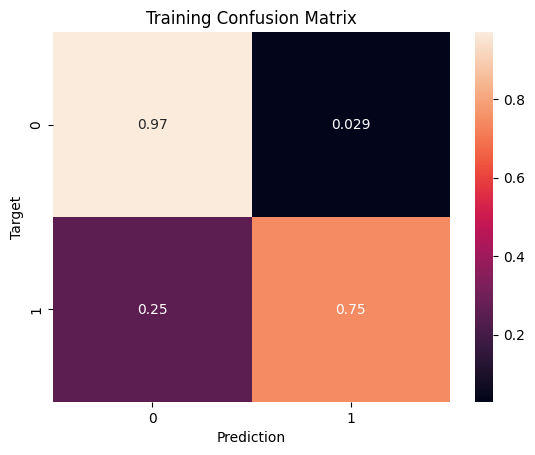

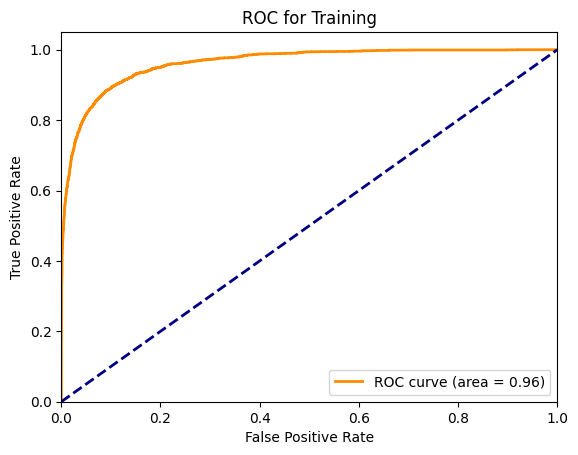

In [20]:
classify_analysis(train_targets, train_inputs, final_clf, 'Training')

F1 score on Validation: 0.7326
AUROC for Validation: 0.9315


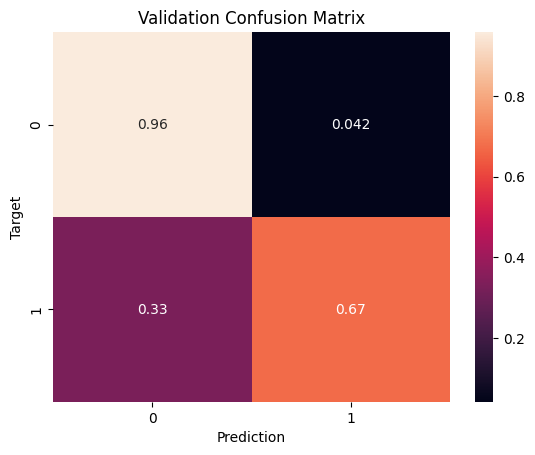

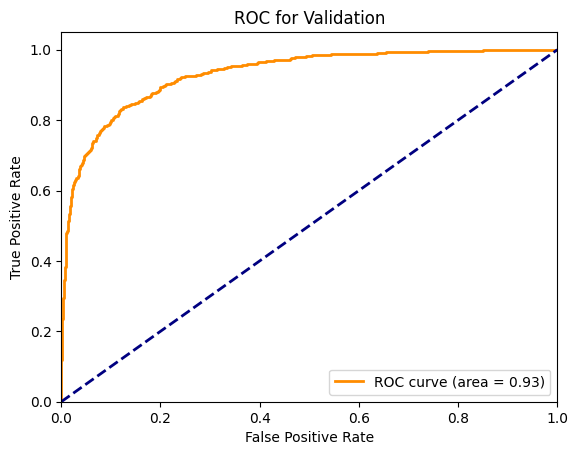

In [21]:
classify_analysis(val_targets, val_inputs, final_clf, 'Validation')

As a result of hyperparameter selection using Hyperopt, a higher quality model was built compared to the model in task 2. However, there are signs of overfitting.

# LightGBM

In [ ]:
%%bash
sudo apt-get update
sudo apt-get install -y build-essential cmake git wget unzip
sudo apt-get install -y libboost-dev libboost-system-dev libboost-filesystem-dev
sudo apt-get install -y libboost-iostreams-dev libboost-program-options-dev libboost-regex-dev
sudo apt-get install -y libboost-thread-dev libboost-chrono-dev libboost-date-time-dev
sudo apt-get install -y libboost-atomic-dev libboost-serialization-dev
sudo apt-get install -y python3-pip

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 https://cli.github.com/packages stable/main amd64 Packages [357 B]
Get:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [85.2 kB]
Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:8 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,389 kB]
Hit:9 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,821 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:12 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Hit:13 https://ppa.launchpadcontent.net/graphics-dr

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 6.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
de

In [ ]:
%%bash
sudo apt-get install -y ocl-icd-libopencl1 clinfo
sudo apt-get install -y nvidia-opencl-dev opencl-headers

Reading package lists...
Building dependency tree...
Reading state information...
clinfo is already the newest version (3.0.21.02.21-1).
ocl-icd-libopencl1 is already the newest version (2.2.14-3).
ocl-icd-libopencl1 set to manually installed.
0 upgraded, 0 newly installed, 0 to remove and 100 not upgraded.
Reading package lists...
Building dependency tree...
Reading state information...
nvidia-opencl-dev is already the newest version (11.5.1-1ubuntu1).
The following NEW packages will be installed:
  opencl-headers
0 upgraded, 1 newly installed, 0 to remove and 100 not upgraded.
Need to get 1,754 B of archives.
After this operation, 12.3 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 opencl-headers all 3.0~2022.01.04-1 [1,754 B]
Fetched 1,754 B in 0s (5,864 B/s)
Selecting previously unselected package opencl-headers.
(Reading database ... 123073 files and directories currently installed.)
Preparing to unpack .../opencl-headers_3.0~

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 


In [ ]:
%%bash
git clone --recursive https://github.com/microsoft/LightGBM
cd LightGBM
mkdir build
cd build
cmake -DUSE_CUDAP=1 ..
make -j4

Submodule path 'external_libs/compute': checked out '36350b7de849300bd3d72a05d8bf890ca405a014'
Submodule path 'external_libs/eigen': checked out '3147391d946bb4b6c68edd901f2add6ac1f31f8c'
Submodule path 'external_libs/fast_double_parser': checked out '252029ddac664370bdda3f0761675785d92a1573'
Submodule path 'external_libs/fast_double_parser/benchmarks/dependencies/abseil-cpp': checked out 'd936052d32a5b7ca08b0199a6724724aea432309'
Submodule path 'external_libs/fast_double_parser/benchmarks/dependencies/double-conversion': checked out 'f4cb2384efa55dee0e6652f8674b05763441ab09'
Submodule path 'external_libs/fmt': checked out '8303d140a1a11f19b982a9f664bbe59a1ccda3f4'
-- The C compiler identification is GNU 11.4.0
-- The CXX compiler identification is GNU 11.4.0
-- Detecting C compiler ABI info
-- Detecting C compiler ABI info - done
-- Check for working C compiler: /usr/bin/cc - skipped
-- Detecting C compile features
-- Detecting C compile features - done
-- Detecting CXX compiler ABI i

Cloning into 'LightGBM'...
Submodule 'include/boost/compute' (https://github.com/boostorg/compute) registered for path 'external_libs/compute'
Submodule 'eigen' (https://gitlab.com/libeigen/eigen.git) registered for path 'external_libs/eigen'
Submodule 'external_libs/fast_double_parser' (https://github.com/lemire/fast_double_parser.git) registered for path 'external_libs/fast_double_parser'
Submodule 'external_libs/fmt' (https://github.com/fmtlib/fmt.git) registered for path 'external_libs/fmt'
Cloning into '/content/LightGBM/external_libs/compute'...
Cloning into '/content/LightGBM/external_libs/eigen'...
Cloning into '/content/LightGBM/external_libs/fast_double_parser'...
Cloning into '/content/LightGBM/external_libs/fmt'...
Submodule 'benchmark/dependencies/abseil-cpp' (https://github.com/abseil/abseil-cpp.git) registered for path 'external_libs/fast_double_parser/benchmarks/dependencies/abseil-cpp'
Submodule 'benchmark/dependencies/double-conversion' (https://github.com/google/doub

In [ ]:
%%bash
cd LightGBM
mkdir -p build
cd build
cmake -DUSE_CUDA=ON ..
make -j4

# Встановлюємо Python пакет з кореневої папки LightGBM
cd ..
python3 -m pip install --upgrade pip
python3 -m pip install .

Process is interrupted.


In [22]:
categorical_index = [train_inputs.columns.get_loc(col) for col in categorical_col]

In [23]:
lgb_clf = lgb.LGBMClassifier(
    max_depth = 5,
    n_estimators = 80,
    #device = 'cuda',
    scale_pos_weight = scale_pos_weight,
    random_state = 42
)

lgb_clf.fit(train_inputs, train_targets, eval_set = [(val_inputs, val_targets)])

[LightGBM] [Info] Number of positive: 2442, number of negative: 9558
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001313 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 843
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203500 -> initscore=-1.364561
[LightGBM] [Info] Start training from score -1.364561
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

LGBMClassifier(max_depth=5, n_estimators=80, random_state=42,
               scale_pos_weight=np.float64(3.914004914004914))

F1 score on Training: 0.7631
AUROC for Training: 0.9573


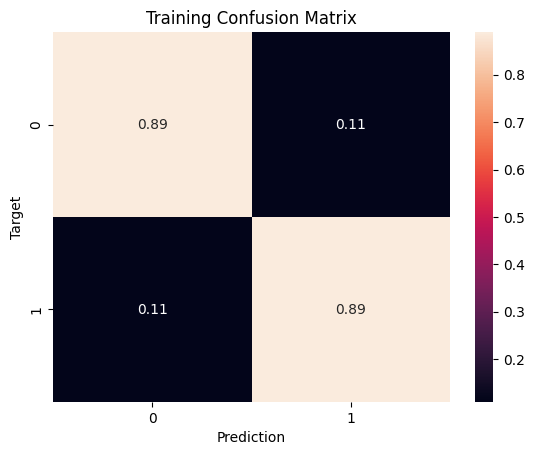

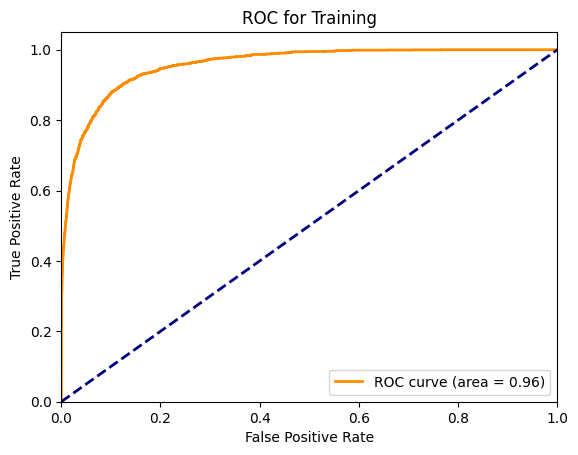

In [24]:
classify_analysis(train_targets, train_inputs, lgb_clf, 'Training')

F1 score on Validation: 0.7176
AUROC for Validation: 0.9335


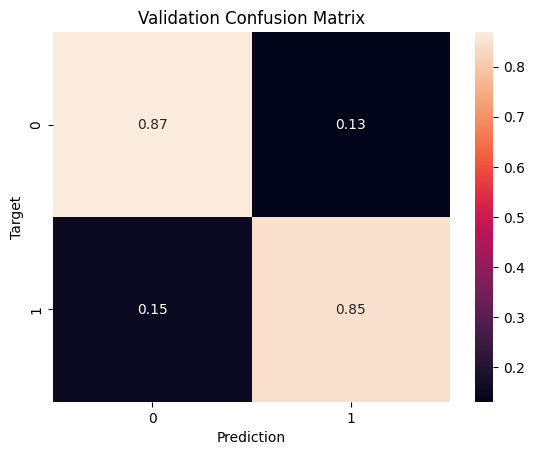

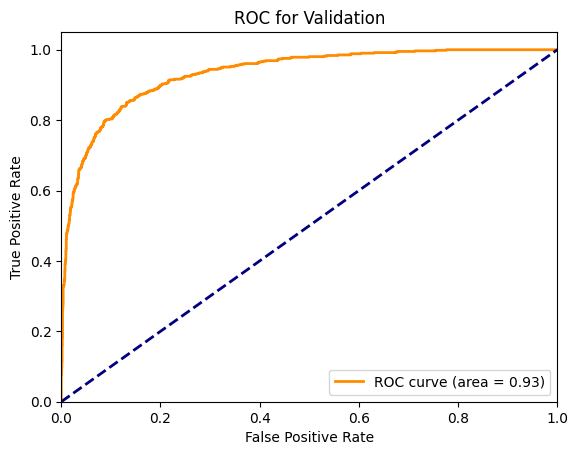

In [25]:
classify_analysis(val_targets, val_inputs, lgb_clf, 'Validation')

The resulting LightGBM model showed a fairly good result, although there are signs of overfitting (the area under the ROC curve on the training set exceeds this metric on the validation set, respectively, there is high variance). At the same time, the model showed a better result than the corresponding one in the case of XGBoost.

# LightGBM and Hyperopt

In [33]:
def objective(params):
    clf = lgb.LGBMClassifier(
        n_estimators = int(params['n_estimators']),
        learning_rate = params['learning_rate'],
        max_depth = int(params['max_depth']),
        num_leaves = int(params['num_leaves']),
        min_child_weight = params['min_child_weight'],
        subsample = params['subsample'],
        colsample_bytree = params['colsample_bytree'],
        reg_alpha = params['reg_alpha'],
        reg_lambda = params['reg_lambda'],
        min_split_gain = params['min_split_gain'],
        cat_feature = categorical_index,
        random_state = 42
    )

    clf.fit(train_inputs, train_targets, eval_set=[(val_inputs, val_targets)])
    pred = clf.predict(val_inputs)
    pred_proba = clf.predict_proba(val_inputs)[:,1]
    fpr, tpr, thresholds = roc_curve(val_targets, pred_proba, pos_label = True)
    roc_auc = auc(fpr, tpr)

    return {'loss': -roc_auc, 'status': STATUS_OK}

# Простір гіперпараметрів
space = {
    'n_estimators': hp.quniform('n_estimators', 50, 500, 5),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),
    'max_depth': hp.quniform('max_depth', 3, 25, 1),
    'num_leaves': hp.quniform('num_leaves', 20, 150, 1),
    'min_child_weight': hp.quniform('min_child_weight', 1, 10, 1),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0),
    'reg_alpha': hp.uniform('reg_alpha', 0, 1),
    'reg_lambda': hp.uniform('reg_lambda', 0, 1),
    'min_split_gain': hp.uniform('min_split_gain', 0, 0.1)
}

In [34]:
# Оптимізація
trials = Trials()
best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=10, trials=trials)

# Перетворення значень гіперпараметрів у кінцеві типи
best['n_estimators'] = int(best['n_estimators'])
best['max_depth'] = int(best['max_depth'])
best['num_leaves'] = int(best['num_leaves'])
best['min_child_weight'] = int(best['min_child_weight'])

print("Найкращі гіперпараметри: ", best)

[LightGBM] [Warning] categorical_feature is set with categorical_column=1,2, will be overridden by cat_feature=1,2. Current value: categorical_feature=1,2
[LightGBM] [Info] Number of positive: 2442, number of negative: 9558
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001474 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 843
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203500 -> initscore=-1.364561
[LightGBM] [Info] Start training from score -1.364561
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

In [35]:
# Навчання фінальної моделі з найкращими гіперпараметрами
final_lgb_clf = lgb.LGBMClassifier(
    n_estimators = best['n_estimators'],
    learning_rate = best['learning_rate'],
    max_depth = best['max_depth'],
    num_leaves = best['num_leaves'],
    min_child_weight = best['min_child_weight'],
    subsample = best['subsample'],
    colsample_bytree = best['colsample_bytree'],
    reg_alpha = best['reg_alpha'],
    reg_lambda = best['reg_lambda'],
    min_split_gain = best['min_split_gain'],
    cat_feature = categorical_index,
    random_state = 42
)

final_lgb_clf.fit(train_inputs, train_targets, eval_set=[(val_inputs, val_targets)])

[LightGBM] [Warning] categorical_feature is set with categorical_column=1,2, will be overridden by cat_feature=1,2. Current value: categorical_feature=1,2
[LightGBM] [Info] Number of positive: 2442, number of negative: 9558
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001402 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 843
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203500 -> initscore=-1.364561
[LightGBM] [Info] Start training from score -1.364561
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

LGBMClassifier(cat_feature=[1, 2],
               colsample_bytree=np.float64(0.6271853370712734),
               learning_rate=np.float64(0.09482938263812032), max_depth=4,
               min_child_weight=3,
               min_split_gain=np.float64(0.06963923867099137), n_estimators=450,
               num_leaves=128, random_state=42,
               reg_alpha=np.float64(0.5936653222677869),
               reg_lambda=np.float64(0.11049662273684013),
               subsample=np.float64(0.9618000451499459))

F1 score on Traning: 0.8105
AUROC for Traning: 0.9663


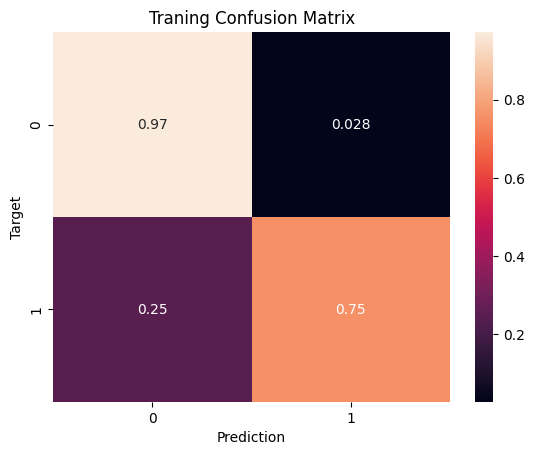

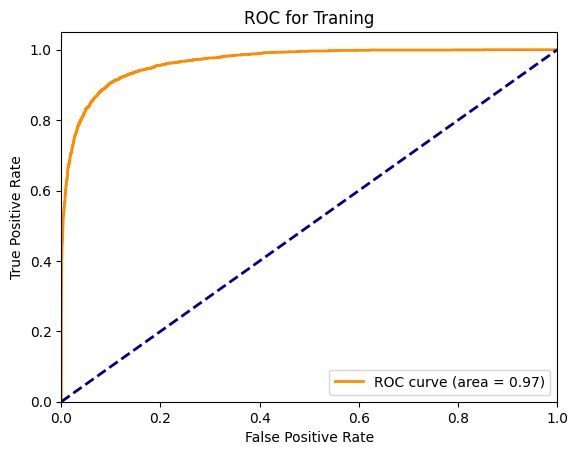

In [36]:
classify_analysis(train_targets, train_inputs, final_lgb_clf, 'Traning')

F1 score on Validation: 0.7314
AUROC for Validation: 0.9321


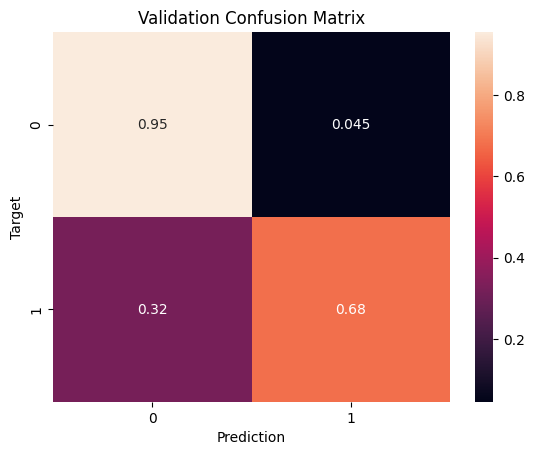

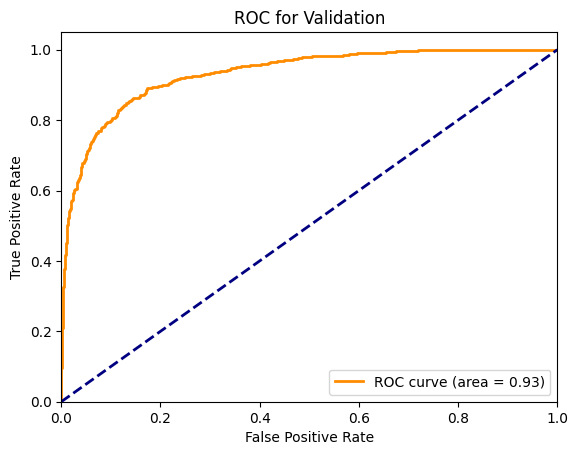

In [37]:
classify_analysis(val_targets, val_inputs, final_lgb_clf, 'Validation')

The resulting model after tuning hyperparameters is less accurate, but of higher quality, compared to the previously considered LightGBM model. At the same time, it is slightly higher quality than the XGBoost model after tuning parameters.

In [58]:
from process_bank_churn import preprocess_data, preprocess_new_data

In [59]:
map_cols = ['Gender']
encoder_cols = ['Geography']
map_codes = {'Female': 1, 'Male': 0}

preprodessed_train_df = preprocess_data(raw_df, target_col, inputs_cols, map_cols, map_codes, encoder_cols, scaler_numeric=True)

In [60]:
X_train = preprodessed_train_df['X_train']
X_val = preprodessed_train_df['X_val']
proc_train_targets = preprodessed_train_df['y_train']
proc_val_targets = preprodessed_train_df['y_val']
encoder = preprodessed_train_df['encoder']
scaler = preprodessed_train_df['scaler']

In [61]:
def objective(params):
  clf = xgb.XGBClassifier(
      n_estimators = int(params['n_estimators']),
      learning_rate = params['learning_rate'],
      max_depth = int(params['max_depth']),
      min_child_weight = params['min_child_weight'],
      subsample = params['subsample'],
      colsample_bytree = params['colsample_bytree'],
      gamma = params['gamma'],
      reg_alpha = params['reg_alpha'],
      reg_lambda = params['reg_lambda'],
      enable_categorical = True,
      missing = np.nan,
      device = 'cuda',
      early_stopping_rounds = 10,
      random_state = 42
    )

  clf.fit(
      X_train,
      train_targets,
      eval_set = [(X_val, proc_val_targets)],
      verbose =2
  )
  pred = clf.predict(X_val)
  pred_proba = clf.predict_proba(X_val)[:,1]
  fpr, tpr, thresholds = roc_curve(proc_val_targets, pred_proba, pos_label = True)
  roc_auc = auc(fpr, tpr)

  return {'loss': -roc_auc, 'status': STATUS_OK}

# простір гіперпараметрів
space = {
    'n_estimators': hp.quniform('n_estimators', 50, 500, 5),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),
    'max_depth': hp.quniform('max_depth', 3, 25, 1),
    'min_child_weight': hp.quniform('min_child_weight', 1, 10, 1),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0),
    'gamma': hp.uniform('gamma', 0, 0.5),
    'reg_alpha': hp.uniform('reg_alpha', 0, 1),
    'reg_lambda': hp.uniform('reg_lambda', 0, 1)
}

In [62]:
# оптимізація
trials = Trials()
best = fmin(fn = objective, space = space, algo = tpe.suggest, max_evals = 20, trials = trials)

# перетворення значень гіперпараметрів у кінцеві типи
best['n_estimators'] = int(best['n_estimators'])
best['max_depth'] = int(best['max_depth'])
best['min_child_weight'] = int(best['min_child_weight'])

print("Найкращі гіперпараметри: ", best)

[0]	validation_0-logloss:0.41620
[2]	validation_0-logloss:0.34039
[4]	validation_0-logloss:0.31132
[6]	validation_0-logloss:0.27842
[8]	validation_0-logloss:0.27041
[10]	validation_0-logloss:0.26865
[12]	validation_0-logloss:0.26761
[14]	validation_0-logloss:0.26590
[16]	validation_0-logloss:0.26600
[18]	validation_0-logloss:0.26755
[20]	validation_0-logloss:0.26740
[22]	validation_0-logloss:0.26859
[24]	validation_0-logloss:0.26869
[0]	validation_0-logloss:0.44593
[2]	validation_0-logloss:0.37422
[4]	validation_0-logloss:0.34513
[6]	validation_0-logloss:0.30753
[8]	validation_0-logloss:0.28802
[10]	validation_0-logloss:0.28086
[12]	validation_0-logloss:0.27275
[14]	validation_0-logloss:0.26583
[16]	validation_0-logloss:0.26332
[18]	validation_0-logloss:0.26162
[20]	validation_0-logloss:0.25905
[22]	validation_0-logloss:0.25734
[24]	validation_0-logloss:0.25698
[26]	validation_0-logloss:0.25702
[28]	validation_0-logloss:0.25712
[30]	validation_0-logloss:0.25632
[32]	validation_0-loglos

In [66]:
# навчання фінальної моделі з найкращими гіперпараметрами
final_clf_pro = xgb.XGBClassifier(
    n_estimators=best['n_estimators'],
    learning_rate=best['learning_rate'],
    max_depth=best['max_depth'],
    min_child_weight=best['min_child_weight'],
    subsample=best['subsample'],
    colsample_bytree=best['colsample_bytree'],
    gamma=best['gamma'],
    reg_alpha=best['reg_alpha'],
    reg_lambda=best['reg_lambda'],
    enable_categorical=True,
    missing=np.nan,
    device='cuda',
    random_state = 42
)

final_clf_pro.fit(X_train, proc_train_targets)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=np.float64(0.5668399729390092), device='cuda',
              early_stopping_rounds=None, enable_categorical=True,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=np.float64(0.23921804420542503), grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=np.float64(0.07548363832339008), max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=9, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=415, n_jobs=None,
              num_parallel_tree=None, ...)

F1 score on Training: 0.763
AUROC for Training: 0.9486


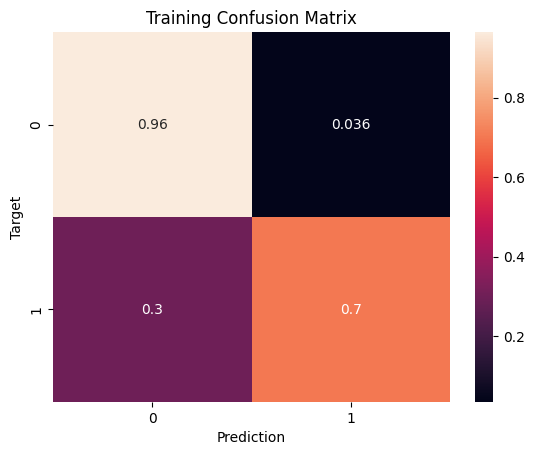

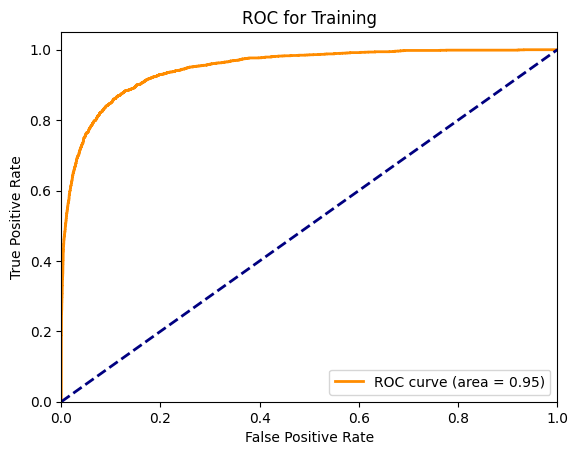

In [67]:
classify_analysis(proc_train_targets, X_train, final_clf_pro, 'Training')

F1 score on Validation: 0.7287
AUROC for Validation: 0.9308


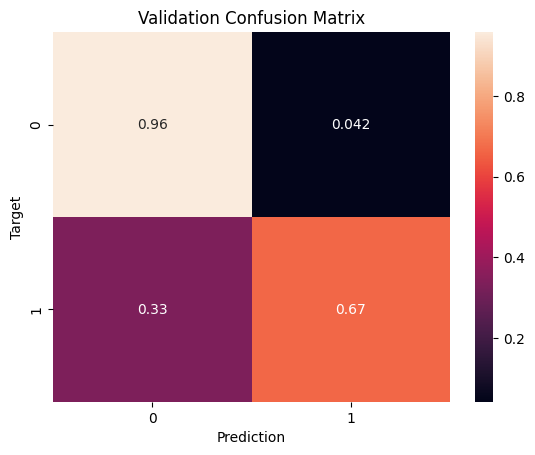

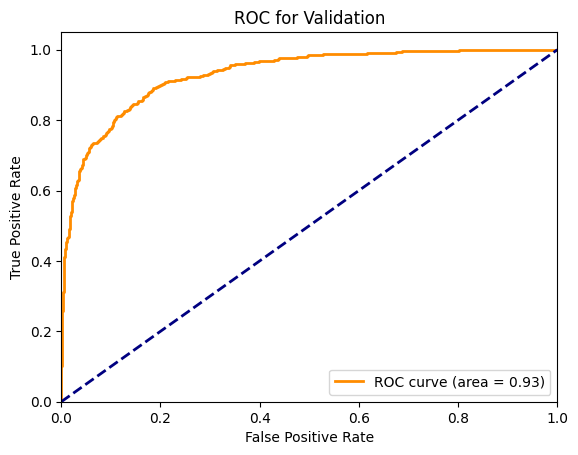

In [68]:
classify_analysis(proc_val_targets, X_val, final_clf_pro, 'Validation')

In [69]:
def objective(params):
    clf = lgb.LGBMClassifier(
        n_estimators = int(params['n_estimators']),
        learning_rate = params['learning_rate'],
        max_depth = int(params['max_depth']),
        num_leaves = int(params['num_leaves']),
        min_child_weight = params['min_child_weight'],
        subsample = params['subsample'],
        colsample_bytree = params['colsample_bytree'],
        reg_alpha = params['reg_alpha'],
        reg_lambda = params['reg_lambda'],
        min_split_gain = params['min_split_gain'],
        cat_feature = categorical_index,
        random_state = 42
    )

    clf.fit(X_train, proc_train_targets, eval_set=[(X_val, proc_val_targets)])
    pred = clf.predict(X_val)
    pred_proba = clf.predict_proba(X_val)[:,1]
    fpr, tpr, thresholds = roc_curve(proc_val_targets, pred_proba, pos_label = True)
    roc_auc = auc(fpr, tpr)

    return {'loss': -roc_auc, 'status': STATUS_OK}

# Простір гіперпараметрів
space = {
    'n_estimators': hp.quniform('n_estimators', 50, 500, 5),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),
    'max_depth': hp.quniform('max_depth', 3, 25, 1),
    'num_leaves': hp.quniform('num_leaves', 20, 150, 1),
    'min_child_weight': hp.quniform('min_child_weight', 1, 10, 1),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0),
    'reg_alpha': hp.uniform('reg_alpha', 0, 1),
    'reg_lambda': hp.uniform('reg_lambda', 0, 1),
    'min_split_gain': hp.uniform('min_split_gain', 0, 0.1)
}

In [70]:
# Оптимізація
trials = Trials()
best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=10, trials=trials)

# Перетворення значень гіперпараметрів у кінцеві типи
best['n_estimators'] = int(best['n_estimators'])
best['max_depth'] = int(best['max_depth'])
best['num_leaves'] = int(best['num_leaves'])
best['min_child_weight'] = int(best['min_child_weight'])

print("Найкращі гіперпараметри: ", best)

[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negativ

In [72]:
# Навчання фінальної моделі з найкращими гіперпараметрами
final_lgb_clf_pro = lgb.LGBMClassifier(
    n_estimators = best['n_estimators'],
    learning_rate = best['learning_rate'],
    max_depth = best['max_depth'],
    num_leaves = best['num_leaves'],
    min_child_weight = best['min_child_weight'],
    subsample = best['subsample'],
    colsample_bytree = best['colsample_bytree'],
    reg_alpha = best['reg_alpha'],
    reg_lambda = best['reg_lambda'],
    min_split_gain = best['min_split_gain'],
    cat_feature = categorical_index,
    random_state = 42
)

final_lgb_clf_pro.fit(X_train, proc_train_targets, eval_set=[(X_val, proc_val_targets)])

[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negativ

LGBMClassifier(cat_feature=[1, 2],
               colsample_bytree=np.float64(0.6043903276669017),
               learning_rate=np.float64(0.10698364651975381), max_depth=5,
               min_child_weight=9,
               min_split_gain=np.float64(0.0012626411673457905),
               n_estimators=75, num_leaves=106, random_state=42,
               reg_alpha=np.float64(0.9262547438136887),
               reg_lambda=np.float64(0.14477639190032554),
               subsample=np.float64(0.702730174939582))

F1 score on Traning: 0.7088
AUROC for Traning: 0.9322


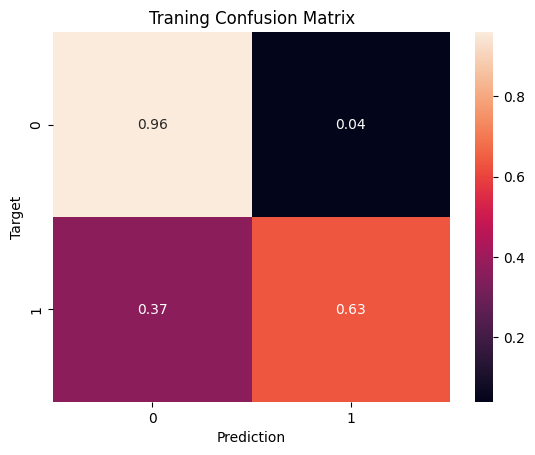

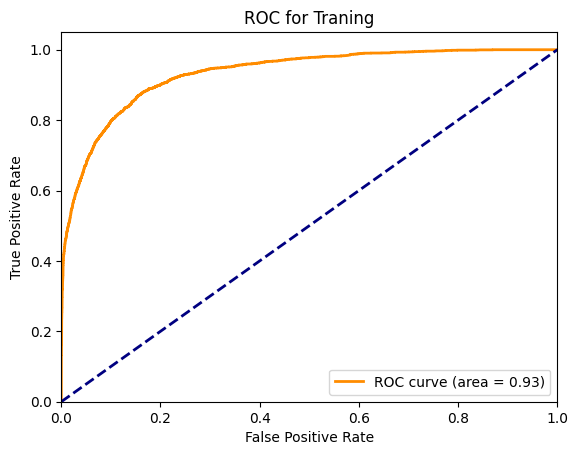

In [74]:
classify_analysis(proc_train_targets, X_train, final_lgb_clf_pro, 'Traning')

F1 score on Validation: 0.6798
AUROC for Validation: 0.9157


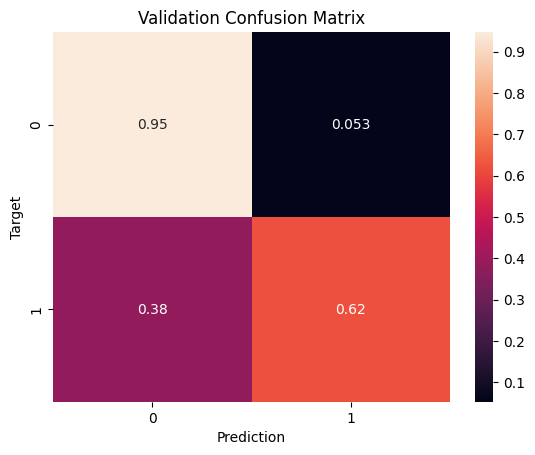

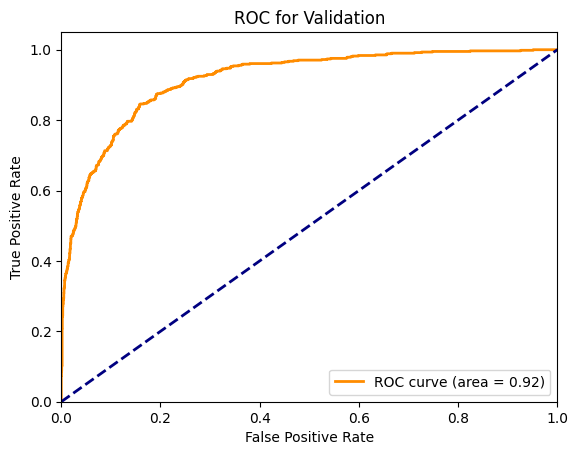

In [75]:
classify_analysis(proc_val_targets, X_val, final_lgb_clf_pro, 'Validation')

The XGBoost model with parameters found using Hyperopt based on processed data (using data standardization and feature encoding) was selected for upload to Kaggle. The model showed quite good results, which, unlike LightGBM, are more robust.

In [84]:
X_test = preprocess_new_data(test_df, inputs_cols, map_cols, map_codes, encoder_cols, encoder, scaler)
X_test.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain
0,-1.034678,-0.944682,-1.087792,1.720173,-1.108193,0.515062,1.016977,0.875226,0.0,1.0,0.0
1,-1.490909,0.161227,-0.009376,-0.717950,0.769304,0.515062,1.016977,-1.109098,1.0,0.0,0.0
2,0.651991,0.652742,1.069040,-0.717950,0.769304,0.515062,-0.983306,0.850584,1.0,0.0,0.0
3,0.804068,0.898500,-0.728320,-0.717950,-1.108193,0.515062,1.016977,1.073044,0.0,0.0,1.0
4,-0.924077,0.652742,1.069040,-0.717950,0.769304,0.515062,1.016977,0.563521,0.0,0.0,1.0


In [85]:
test_df['Exited'] = final_clf_pro.predict_proba(X_test)[:,1]

In [86]:
submission = pd.read_csv('sample_submission.csv')

In [87]:
submission['Exited'] = test_df['Exited']

In [88]:
submission.head()

,id,Exited
0,15000,0.076604
1,15001,0.012319
2,15002,0.079101
3,15003,0.567359
4,15004,0.043629


In [89]:
submission.to_csv('submission_boosting.csv', index = False)

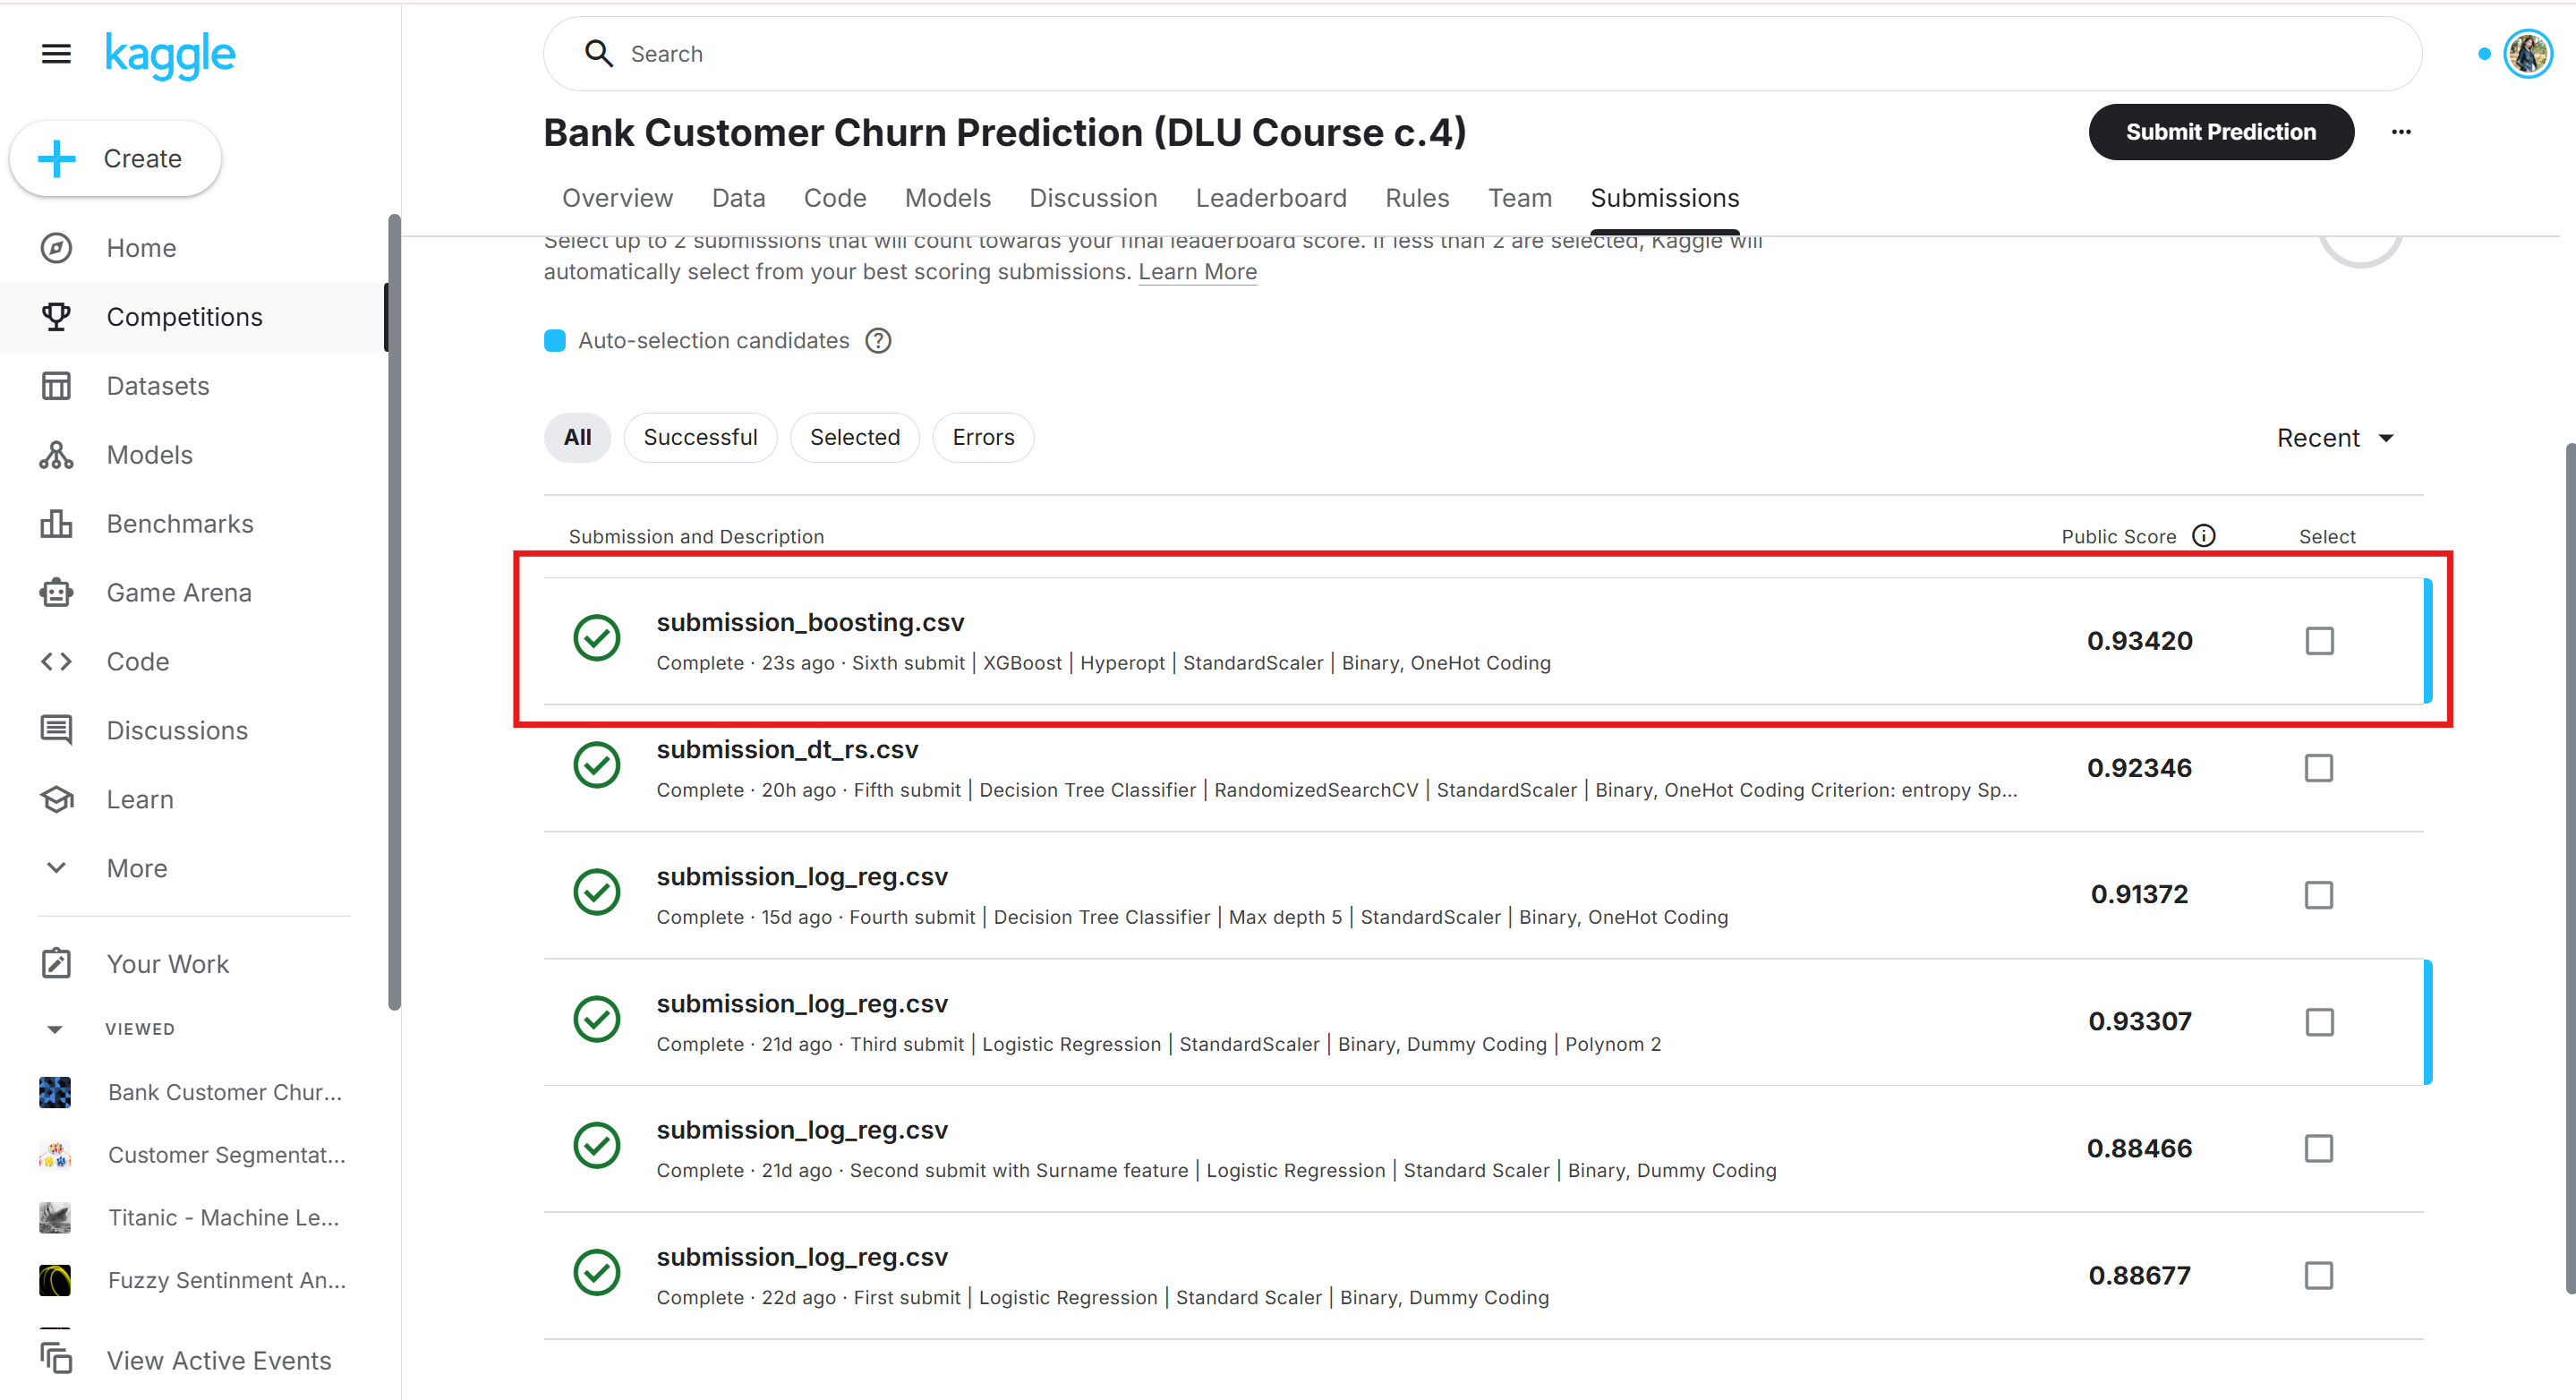

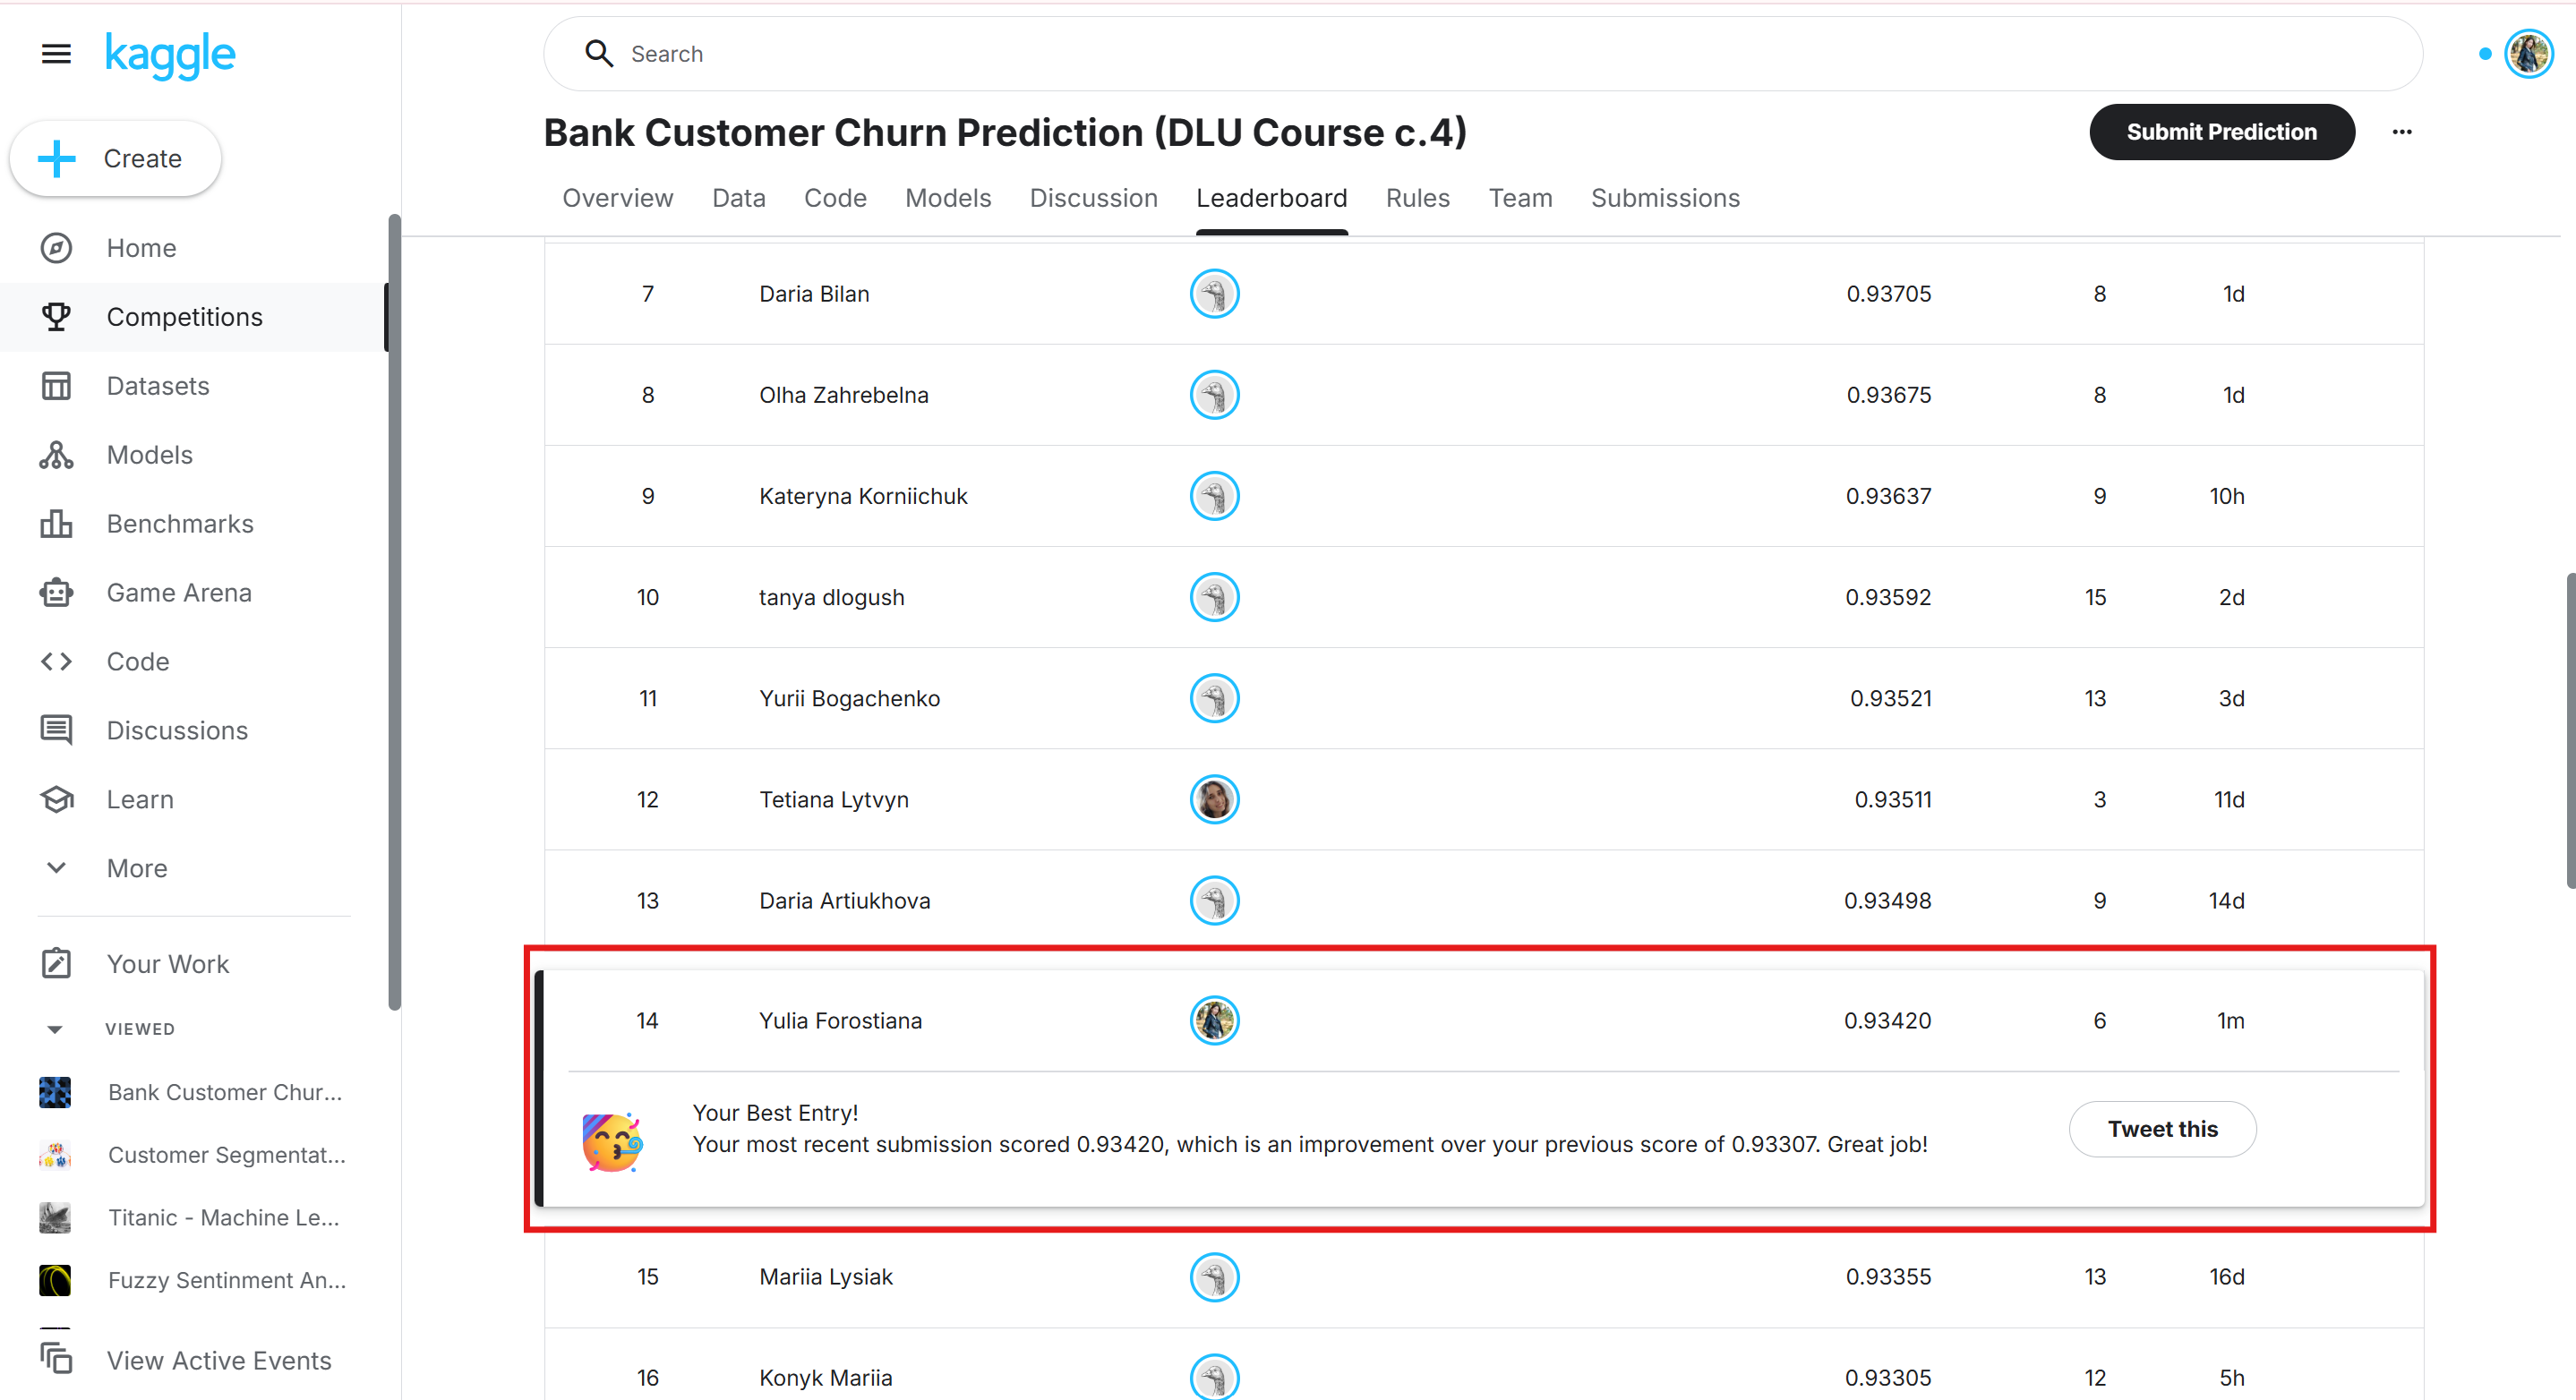